<a href="https://colab.research.google.com/github/hurryzyn/hearwell-analysis/blob/main/Hearwell_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
gimport pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

In [ ]:
folder_id = '1ce8YoXPIAOQeuoK6kfXbJwAjooGAQQfN'
gdown.download_folder(id=folder_id, remaining_ok=True, quiet=True)
file_path = 'HWL/Hearing well-being Survey Report.csv'
df = pd.read_csv(file_path)
df.head()

,Perceived_Hearing_Meaning,Hearing_FOMO,Hearing_Test_Barrier,Missed_Important_Sounds,Left_Out_Due_To_Hearing,Daily_Headphone_Use,Belief_Early_Hearing_Care,Last_Hearing_Test_Method,Interest_in_Hearing_App,Desired_App_Features,Awareness_on_hearing_and_Willingness_to_invest,Paid_App_Test_Interest,Age_group,Ear_Discomfort_After_Use
0,"Staying independent and alert, Enjoying music,...",Sometimes,Cost,"Yes, in family conversations","Yes, often",My parent(s),5,"Self - application, Loved one, AI Support",Yes,"Privacy, Soft guidance, Visuals, Report sharin...",Yes,"Maybe, if it offers good value",18 - 24,No
1,"Staying independent and alert, Staying connect...",Rarely,Never felt the need,"Yes, in public spaces (trains, shops, announce...",Only in noisy places,My child/children,5,Self - application,Yes,Privacy,Yes,"No, I prefer getting tested at a hospital",18 - 24,Yes
2,"Staying independent and alert, I havenâ€™t tho...",Rarely,Shame,"Yes, during important work or school meetings",Sometimes,My parent(s),5,Self - application,Maybe,Soft guidance,No,"Yes, definitely",18 - 24,Maybe
3,Staying independent and alert,Yes often,Lack of awareness,"Yes, during important work or school meetings",Sometimes,1-2 hours,4,I've never taken a hearing test,"Yes, that would be helpful",Game-based interaction,Yes,"Yes, definitely",18 - 24,Occasionally
4,Staying independent and alert,Never,Lack of awareness,"No, I usually hear things well",Only in noisy places,Less than 1 hour,5,I've never taken a hearing test,"No, I don't think it's necessary","Quick tests, Game-based interaction, Detailed ...",No,"No, I prefer getting tested at a hospital",25 - 34,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 14 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Perceived_Hearing_Meaning                       387 non-null    object
 1   Hearing_FOMO                                    387 non-null    object
 2   Hearing_Test_Barrier                            385 non-null    object
 3   Missed_Important_Sounds                         387 non-null    object
 4   Left_Out_Due_To_Hearing                         387 non-null    object
 5   Daily_Headphone_Use                             387 non-null    object
 6   Belief_Early_Hearing_Care                       387 non-null    int64 
 7   Last_Hearing_Test_Method                        387 non-null    object
 8   Interest_in_Hearing_App                         387 non-null    object
 9   Desired_App_Features                            387 no

In [ ]:
print(df.isnull().sum())

Perceived_Hearing_Meaning                         0
Hearing_FOMO                                      0
Hearing_Test_Barrier                              2
Missed_Important_Sounds                           0
Left_Out_Due_To_Hearing                           0
Daily_Headphone_Use                               0
Belief_Early_Hearing_Care                         0
Last_Hearing_Test_Method                          0
Interest_in_Hearing_App                           0
Desired_App_Features                              0
Awareness_on_hearing_and_Willingness_to_invest    0
Paid_App_Test_Interest                            0
Age_group                                         0
Ear_Discomfort_After_Use                          0
dtype: int64


In [ ]:
print(df['Age_group'].value_counts())

Age_group
18 - 24     287
35 - 44      30
45 - 54      28
25 - 34      24
Under 18     13
55 - 64       5
Name: count, dtype: int64


In [ ]:
print(df['Daily_Headphone_Use'].value_counts())

Daily_Headphone_Use
Less than 1 hour     148
1-2 hours            113
2-4 hours             79
More than 4 hours     44
My parent(s)           2
My child/children      1
Name: count, dtype: int64


In [ ]:
object_columns = df.select_dtypes(include=['object']).columns

for column in object_columns:
    print(f"-- Distribusi Jawaban untuk Kolom: {column} ---")
    print(df[column].value_counts())
    print("\n" + "="*50 + "\n")


-- Distribusi Jawaban untuk Kolom: Perceived_Hearing_Meaning ---
Perceived_Hearing_Meaning
Staying connected with the world                                                                                                                                       78
Enjoying music, laughter, and life                                                                                                                                     77
Feeling close to loved ones                                                                                                                                            36
Enjoying music, laughter, and life, Staying connected with the world                                                                                                   33
I havenâ€™t thought about it much                                                                                                                                      32
Staying independent and alert                              

In [ ]:
df_cleaned = df.copy()
df_cleaned.dropna(inplace=True)
values_to_remove = ['My parent(s)', 'My child/children']

df_cleaned = df_cleaned[~df_cleaned['Daily_Headphone_Use'].isin(values_to_remove)]

print("Proses pembersihan data selesai.")
print(f"Jumlah baris awal: {len(df)}")
print(f"Jumlah baris setelah dibersihkan: {len(df_cleaned)}")


Proses pembersihan data selesai.
Jumlah baris awal: 387
Jumlah baris setelah dibersihkan: 382


In [ ]:
print(df_cleaned['Daily_Headphone_Use'].unique())

['1-2 hours' 'Less than 1 hour' '2-4 hours' 'More than 4 hours']


/tmp/ipykernel_8067/3193289030.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_counts.values, y=truncated_labels, palette='plasma', orient='h')


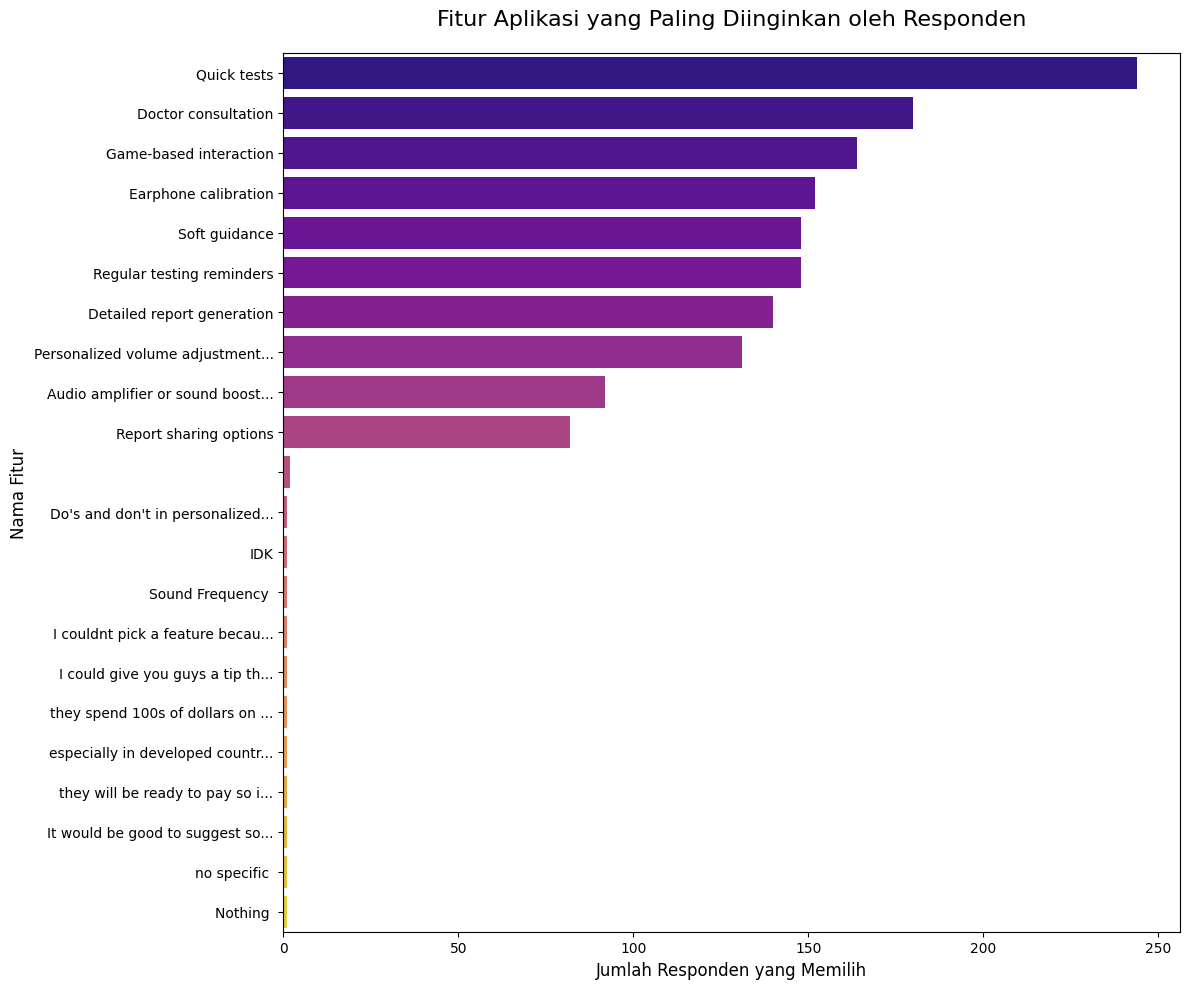

In [ ]:

all_features = df_cleaned['Desired_App_Features'].str.split(', ').explode()
feature_counts = all_features.value_counts()



limit = 30
truncated_labels = [label[:limit] + '...' if len(label) > limit else label for label in feature_counts.index]


plt.figure(figsize=(12, 10))

sns.barplot(x=feature_counts.values, y=truncated_labels, palette='plasma', orient='h')

plt.title('Fitur Aplikasi yang Paling Diinginkan oleh Responden', fontsize=16, pad=20)
plt.xlabel('Jumlah Responden yang Memilih', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)


plt.tight_layout()
plt.show()

--- Visualisasi: Distribusi Usia Responden ---


/tmp/ipykernel_8067/4003882609.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned['Age_group'], palette='viridis', order=order)


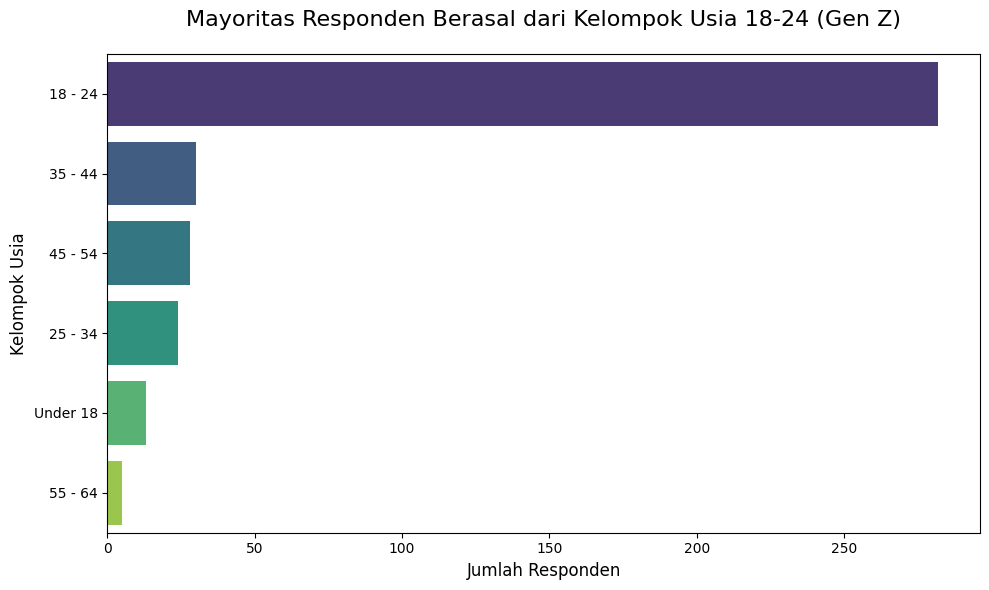

In [ ]:
print("--- Visualisasi: Distribusi Usia Responden ---")

plt.figure(figsize=(10, 6))

order = df_cleaned['Age_group'].value_counts().index
sns.countplot(y=df_cleaned['Age_group'], palette='viridis', order=order)

plt.title('Mayoritas Responden Berasal dari Kelompok Usia 18-24 (Gen Z)', fontsize=16, pad=20)
plt.xlabel('Jumlah Responden', fontsize=12)
plt.ylabel('Kelompok Usia', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_8067/510148142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], y=df_cleaned['Age_group'], palette='viridis', order=df_cleaned['Age_group'].value_counts().index)
/tmp/ipykernel_8067/510148142.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=barrier_counts.values, y=barrier_counts.index, palette='plasma')


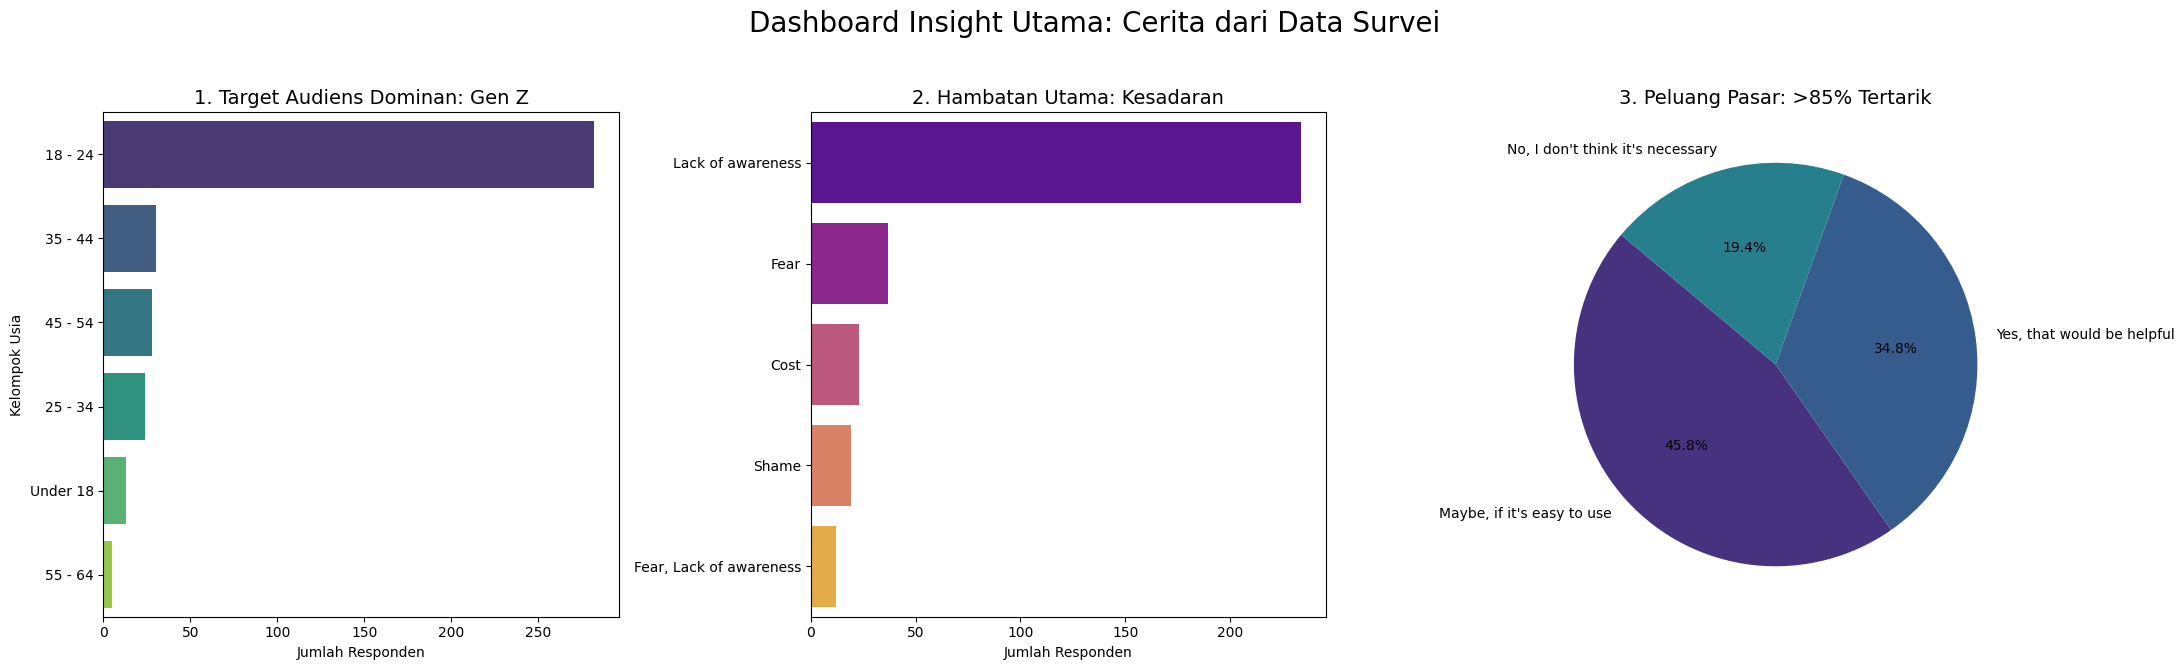

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))


fig.suptitle('Dashboard Insight Utama: Cerita dari Data Survei', fontsize=20)


sns.countplot(ax=axes[0], y=df_cleaned['Age_group'], palette='viridis', order=df_cleaned['Age_group'].value_counts().index)
axes[0].set_title('1. Target Audiens Dominan: Gen Z', fontsize=14)
axes[0].set_xlabel('Jumlah Responden')
axes[0].set_ylabel('Kelompok Usia')


barrier_counts = df_cleaned['Hearing_Test_Barrier'].value_counts().nlargest(5)
sns.barplot(ax=axes[1], x=barrier_counts.values, y=barrier_counts.index, palette='plasma')
axes[1].set_title('2. Hambatan Utama: Kesadaran', fontsize=14)
axes[1].set_xlabel('Jumlah Responden')
axes[1].set_ylabel('')


interest_counts = df_cleaned['Interest_in_Hearing_App'].value_counts()
axes[2].pie(interest_counts, labels=interest_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
axes[2].set_title('3. Peluang Pasar: >85% Tertarik', fontsize=14)
axes[2].set_ylabel('')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

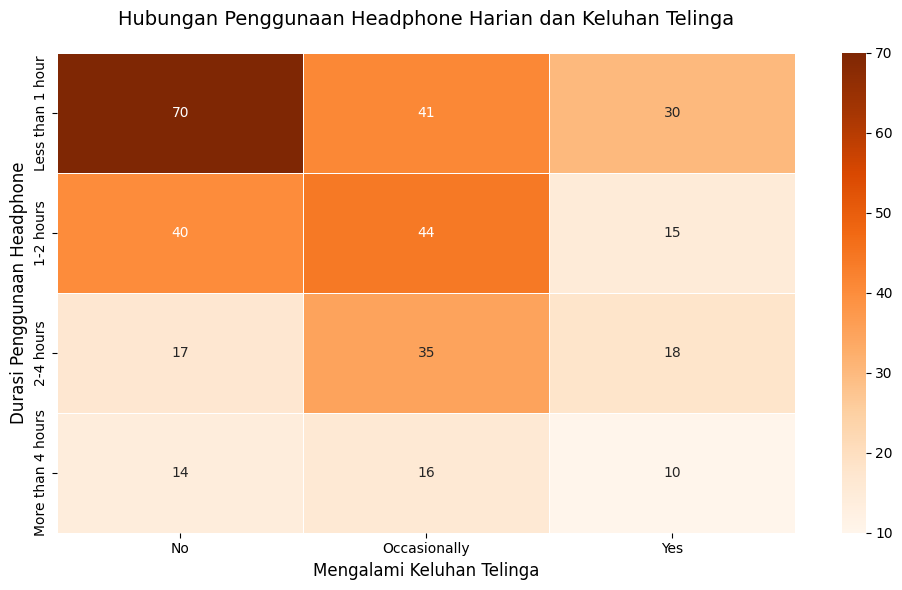

--------------------------------------------------
Hasil Uji Chi-Square
--------------------------------------------------
P-Value: 0.00934
Kesimpulan: P-Value < 0.05. Terdapat hubungan statistik yang SIGNIFIKAN antara durasi penggunaan headphone dengan keluhan telinga responden.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


df_filtered = df_cleaned[~df_cleaned['Ear_Discomfort_After_Use'].isin(['Not sure', 'Maybe'])].copy()


crosstab = pd.crosstab(df_filtered['Daily_Headphone_Use'], df_filtered['Ear_Discomfort_After_Use'])

duration_order = ['Less than 1 hour', '1-2 hours', '2-4 hours', 'More than 4 hours']
discomfort_order = ['No', 'Occasionally', 'Yes']

crosstab = crosstab.reindex(index=duration_order, columns=discomfort_order)


plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Oranges', linewidths=.5)
plt.title('Hubungan Penggunaan Headphone Harian dan Keluhan Telinga', fontsize=14, pad=20)
plt.xlabel('Mengalami Keluhan Telinga', fontsize=12)
plt.ylabel('Durasi Penggunaan Headphone', fontsize=12)
plt.tight_layout()
plt.show()


chi2, p, dof, expected = chi2_contingency(crosstab)

print("-" * 50)
print(f"Hasil Uji Chi-Square")
print("-" * 50)
print(f"P-Value: {p:.5f}")


if p < 0.05:
    print("Kesimpulan: P-Value < 0.05. Terdapat hubungan statistik yang SIGNIFIKAN antara durasi penggunaan headphone dengan keluhan telinga responden.")
else:
    print("Kesimpulan: P-Value >= 0.05. TIDAK terdapat hubungan statistik yang signifikan (perbedaan bisa jadi karena kebetulan).")

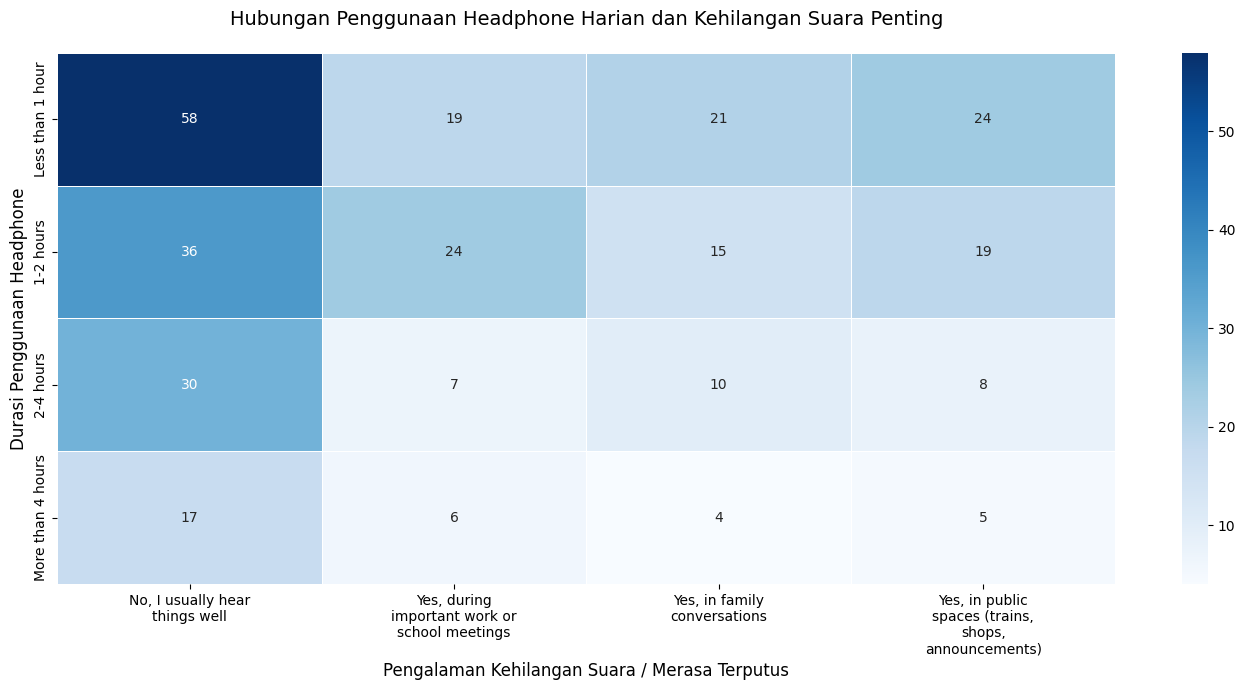

--------------------------------------------------
Hasil Uji Chi-Square
--------------------------------------------------
P-Value: 0.55093
Kesimpulan: P-Value >= 0.05. TIDAK terdapat hubungan statistik yang signifikan (perbedaan bisa jadi karena kebetulan).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import textwrap


main_responses = [
    'No, I usually hear things well',
    'I’m not sure, but I have felt disconnected',
    'Yes, during important work or school meetings',
    'Yes, in public spaces (trains, shops, announcements)',
    'Yes, in family conversations'
]
df_filtered_sounds = df_cleaned[df_cleaned['Missed_Important_Sounds'].isin(main_responses)].copy()


crosstab_sounds = pd.crosstab(df_filtered_sounds['Daily_Headphone_Use'], df_filtered_sounds['Missed_Important_Sounds'])


duration_order = ['Less than 1 hour', '1-2 hours', '2-4 hours', 'More than 4 hours']
crosstab_sounds = crosstab_sounds.reindex(index=duration_order)

short_labels = [textwrap.fill(label, 20) for label in crosstab_sounds.columns]

plt.figure(figsize=(14, 7))
sns.heatmap(crosstab_sounds, annot=True, fmt='d', cmap='Blues', linewidths=.5, xticklabels=short_labels)
plt.title('Hubungan Penggunaan Headphone Harian dan Kehilangan Suara Penting', fontsize=14, pad=20)
plt.xlabel('Pengalaman Kehilangan Suara / Merasa Terputus', fontsize=12)
plt.ylabel('Durasi Penggunaan Headphone', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

chi2_sounds, p_sounds, dof_sounds, expected_sounds = chi2_contingency(crosstab_sounds)

print("-" * 50)
print(f"Hasil Uji Chi-Square")
print("-" * 50)
print(f"P-Value: {p_sounds:.5f}")

if p_sounds < 0.05:
    print("Kesimpulan: P-Value < 0.05. Terdapat hubungan statistik yang SIGNIFIKAN antara durasi penggunaan headphone dengan pengalaman kehilangan suara penting.")
else:
    print("Kesimpulan: P-Value >= 0.05. TIDAK terdapat hubungan statistik yang signifikan (perbedaan bisa jadi karena kebetulan).")

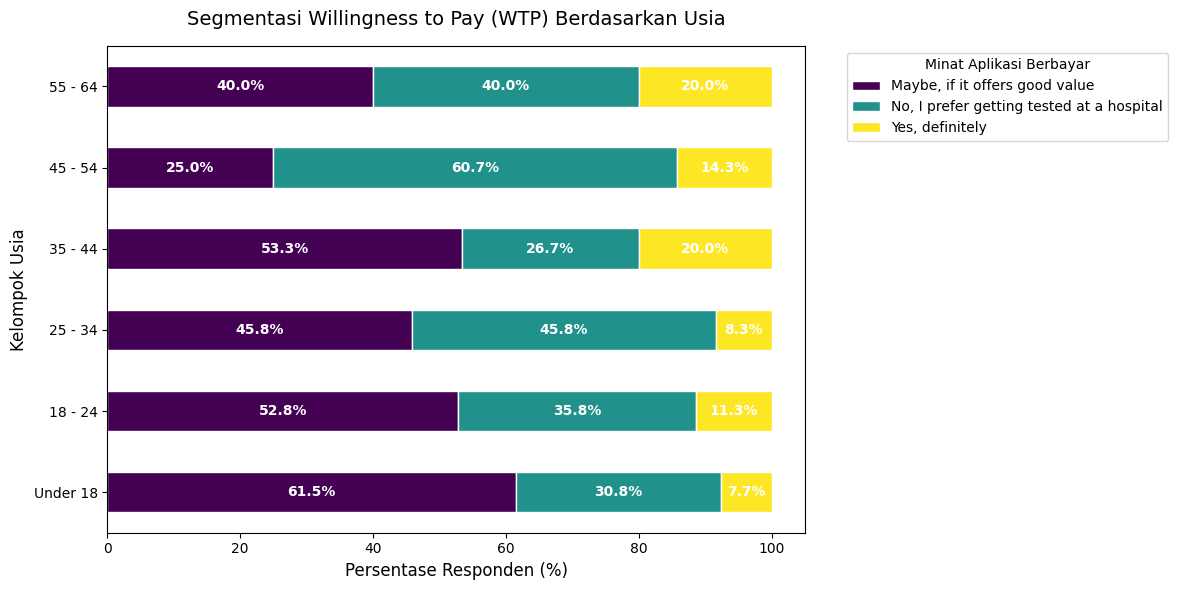

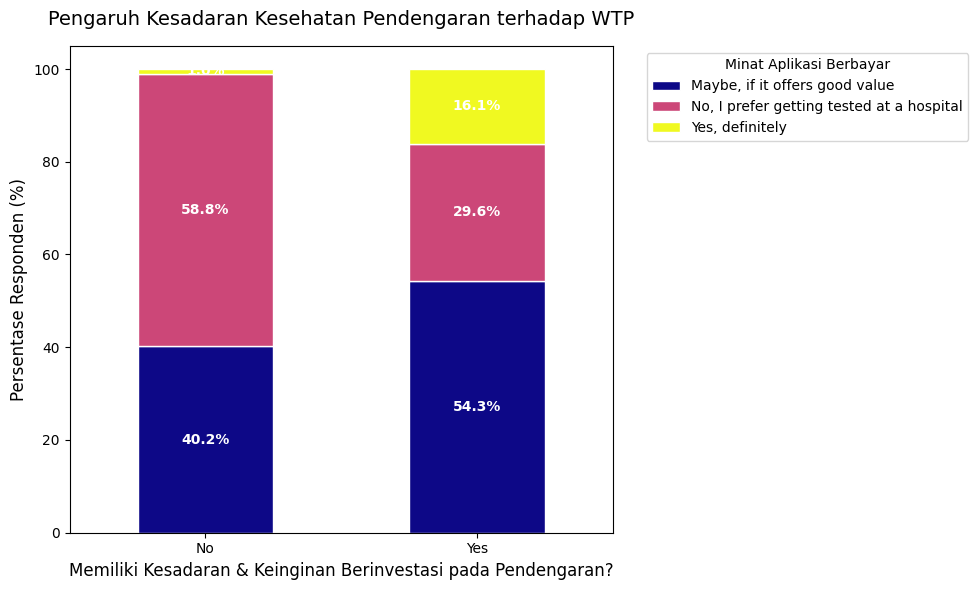

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

wtp_age = pd.crosstab(df_cleaned['Age_group'], df_cleaned['Paid_App_Test_Interest'], normalize='index') * 100

age_order = ['Under 18', '18 - 24', '25 - 34', '35 - 44', '45 - 54', '55 - 64']
wtp_age = wtp_age.reindex(age_order)

fig, ax1 = plt.subplots(figsize=(12, 6))
wtp_age.plot(kind='barh', stacked=True, ax=ax1, colormap='viridis', edgecolor='white')

ax1.set_title('Segmentasi Willingness to Pay (WTP) Berdasarkan Usia', fontsize=14, pad=15)
ax1.set_xlabel('Persentase Responden (%)', fontsize=12)
ax1.set_ylabel('Kelompok Usia', fontsize=12)
ax1.legend(title='Minat Aplikasi Berbayar', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax1.containers:
    ax1.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


wtp_aware = pd.crosstab(df_cleaned['Awareness_on_hearing_and_Willingness_to_invest'], df_cleaned['Paid_App_Test_Interest'], normalize='index') * 100

fig, ax2 = plt.subplots(figsize=(10, 6))
wtp_aware.plot(kind='bar', stacked=True, ax=ax2, colormap='plasma', edgecolor='white')

ax2.set_title('Pengaruh Kesadaran Kesehatan Pendengaran terhadap WTP', fontsize=14, pad=15)
ax2.set_ylabel('Persentase Responden (%)', fontsize=12)
ax2.set_xlabel('Memiliki Kesadaran & Keinginan Berinvestasi pada Pendengaran?', fontsize=12)
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Minat Aplikasi Berbayar', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()